# Trabajo de Fin de Grado: Desarrollo y Evaluacion de un Metodo Cuantico de Seleccion de Caracteristicas

## Notebook 09 - Fase 9: Evaluacion QFS e Integracion Final

Esta fase toma los subconjuntos QFS seleccionados en la Fase 8, entrena los cuatro modelos del protocolo de Fase 6 y compara el mejor QFS operativo por dataset contra el baseline clasico disponible en test. Tambien conserva el subconjunto del oraculo de Muecke como control teorico separado.

## Importacion y Rutas

In [1]:
import os
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Image, Markdown, display
from sklearn.exceptions import ConvergenceWarning

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from phase6_modeling import pipeline as p6

TABLE8 = PROJECT_ROOT / "results" / "tables" / "08_quantum"
FIG8 = PROJECT_ROOT / "results" / "figures" / "08_quantum"
PRED8 = PROJECT_ROOT / "results" / "predictions" / "08_quantum"
TABLE7 = PROJECT_ROOT / "results" / "tables" / "07_final_comparison"
for folder in [TABLE8, FIG8, PRED8, TABLE7]:
    folder.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

DATASETS = p6.DATASETS
MODEL_NAMES = p6.MODEL_NAMES
UMBRAL_EFECTO_PRACTICO = 0.01
print(f"Proyecto: {PROJECT_ROOT}")
print(f"Modelos evaluados: {MODEL_NAMES}")

Proyecto: /home/gosacar/TFG - QFS Last Chance Claude
Modelos evaluados: ['logistic_regression', 'linear_svm', 'random_forest', 'xgboost']


## 9.1 Materializacion de Subconjuntos QFS

In [2]:
selected_qfs = pd.read_csv(TABLE8 / "qfs_selected_all.csv")
display(selected_qfs)

paths6 = p6.phase6_paths(PROJECT_ROOT)


def feature_list(value):
    return [item for item in str(value).split("|") if item and item != "nan"]


def cargar_split_qfs(dataset, split, features):
    X, y = p6.cargar_split_crudo(paths6, dataset, split)
    if any(feature not in X.columns for feature in features):
        X = pd.get_dummies(X, drop_first=False)
        for feature in features:
            if feature not in X.columns:
                X[feature] = 0
    missing = [feature for feature in features if feature not in X.columns]
    if missing:
        raise KeyError(f"{dataset}/{split}: features QFS ausentes: {missing[:5]}")
    return X[features].copy(), y


materializacion = []
for row in selected_qfs.itertuples(index=False):
    features = feature_list(row.selected_features)
    for split in ["train", "validation", "test"]:
        X, y = cargar_split_qfs(row.dataset, split, features)
        materializacion.append({
            "dataset": row.dataset,
            "configuration": row.configuration,
            "split": split,
            "n_rows": len(X),
            "n_features": X.shape[1],
            "k": int(row.k),
        })
materializacion = pd.DataFrame(materializacion)
materializacion.to_csv(TABLE8 / "qfs_materialized_splits.csv", index=False)
display(materializacion)

,dataset,configuration,alpha,beta,k,n_features,selected_features,validation_macro_f1,validation_balanced_accuracy,validation_accuracy,fit_seconds
0,breast_cancer_wisconsin,qfs_na,0.500000,0.1,10,10,texture_worst|concave_points_mean|radius_mean|...,0.974941,0.974941,0.976471,0.267125
1,breast_cancer_wisconsin,qfs_oracle_mucke,0.953125,NaN,10,10,concave_points_worst|texture_worst|concave_poi...,0.925699,0.931014,0.929412,0.267410
2,customer_churn,qfs_na,0.500000,0.9,10,10,age|support_calls|payment_delay|total_spend|ge...,0.985347,0.987242,0.985558,1.046335
3,customer_churn,qfs_oracle_mucke,0.875000,NaN,10,10,age|tenure|usage_frequency|support_calls|payme...,0.993113,0.994006,0.993225,1.035445
4,madelon,qfs_na,0.500000,0.1,10,10,feat_241|feat_43|feat_205|feat_147|feat_346|fe...,0.583329,0.583333,0.583333,0.323609
5,madelon,qfs_oracle_mucke,0.982422,NaN,10,10,feat_241|feat_43|feat_205|feat_147|feat_368|fe...,0.553333,0.553333,0.553333,0.275839
6,olive_oil_3class,qfs_na,0.500000,0.0,5,5,stearic|linolenic|arachidic|eicosenoic|other,1.000000,1.000000,1.000000,0.248644
7,olive_oil_3class,qfs_oracle_mucke,0.875000,NaN,5,5,linoleic|linolenic|arachidic|eicosenoic|other,1.000000,1.000000,1.000000,0.258405
8,olive_oil_9class,qfs_na,0.500000,0.2,5,5,oleic|linoleic|linolenic|arachidic|other,0.957227,0.953263,0.965116,0.288412
9,olive_oil_9class,qfs_oracle_mucke,0.750000,NaN,5,5,stearic|oleic|linolenic|arachidic|other,0.854498,0.856702,0.906977,0.230392


,dataset,configuration,split,n_rows,n_features,k
0,breast_cancer_wisconsin,qfs_na,train,398,10,10
1,breast_cancer_wisconsin,qfs_na,validation,85,10,10
2,breast_cancer_wisconsin,qfs_na,test,86,10,10
3,breast_cancer_wisconsin,qfs_oracle_mucke,train,398,10,10
4,breast_cancer_wisconsin,qfs_oracle_mucke,validation,85,10,10
5,breast_cancer_wisconsin,qfs_oracle_mucke,test,86,10,10
6,customer_churn,qfs_na,train,308582,10,10
7,customer_churn,qfs_na,validation,66125,10,10
8,customer_churn,qfs_na,test,66125,10,10
9,customer_churn,qfs_oracle_mucke,train,308582,10,10


Los subconjuntos QFS se materializan desde los splits cerrados de Fase 4. En `customer_churn`, el handoff QFS usa variables one-hot, mientras los splits conservan categoricas crudas; por eso se materializan dummies del split y se seleccionan solo las columnas QFS fijadas previamente.

## 9.2 Entrenamiento con los Cuatro Modelos de Fase 6

In [3]:
def experiment_id(dataset, configuration, model_name):
    return f"{dataset}__{configuration}__{model_name}"


def filas_prediccion_qfs(meta, split, y_true, y_pred):
    return [
        {
            "experiment_id": meta["experiment_id"],
            "dataset": meta["dataset"],
            "feature_set": meta["feature_set"],
            "configuration": meta["configuration"],
            "model_name": meta["model_name"],
            "split": split,
            "row_position": int(i),
            "y_true": yt,
            "y_pred": yp,
            "correct": bool(yt == yp),
        }
        for i, (yt, yp) in enumerate(zip(y_true.to_numpy(), y_pred))
    ]


def entrenar_qfs(row, model_name):
    features = feature_list(row.selected_features)
    X_train, y_train = cargar_split_qfs(row.dataset, "train", features)
    X_val, y_val = cargar_split_qfs(row.dataset, "validation", features)
    X_test, y_test = cargar_split_qfs(row.dataset, "test", features)
    estimator = p6.construir_pipeline_modelo(model_name, X_train)
    started = time.perf_counter()
    estimator.fit(X_train, y_train)
    fit_seconds = time.perf_counter() - started

    y_val_pred = estimator.predict(X_val)
    val_score = p6.extraer_score_binario(estimator, X_val) if row.dataset in p6.BINARY_DATASETS else None
    val_metrics = p6.calcular_metricas(y_val, y_val_pred, val_score)

    y_test_pred = estimator.predict(X_test)
    test_score = p6.extraer_score_binario(estimator, X_test) if row.dataset in p6.BINARY_DATASETS else None
    test_metrics = p6.calcular_metricas(y_test, y_test_pred, test_score)

    meta = {
        "experiment_id": experiment_id(row.dataset, row.configuration, model_name),
        "dataset": row.dataset,
        "feature_set": row.configuration,
        "configuration": row.configuration,
        "model_name": model_name,
    }
    result = {
        **meta,
        "alpha": float(row.alpha),
        "beta": row.beta,
        "k": int(row.k),
        "n_features_used": len(features),
        "selected_features": row.selected_features,
        "fit_seconds": fit_seconds,
        "validation_macro_f1": val_metrics["macro_f1"],
        "validation_balanced_accuracy": val_metrics["balanced_accuracy"],
        "validation_accuracy": val_metrics["accuracy"],
        "test_macro_f1": test_metrics["macro_f1"],
        "test_balanced_accuracy": test_metrics["balanced_accuracy"],
        "test_accuracy": test_metrics["accuracy"],
        "test_auc_roc": test_metrics.get("auc_roc", np.nan),
        "n_test": len(y_test),
    }
    preds_val = pd.DataFrame(filas_prediccion_qfs(meta, "validation", y_val, y_val_pred))
    preds_test = pd.DataFrame(filas_prediccion_qfs(meta, "test", y_test, y_test_pred))
    return result, preds_val, preds_test


results = []
preds_val = []
preds_test = []
for row in selected_qfs.itertuples(index=False):
    for model_name in MODEL_NAMES:
        result, pv, pt = entrenar_qfs(row, model_name)
        results.append(result)
        preds_val.append(pv)
        preds_test.append(pt)

qfs_results = pd.DataFrame(results)
qfs_val_predictions = pd.concat(preds_val, ignore_index=True)
qfs_test_predictions = pd.concat(preds_test, ignore_index=True)

qfs_results.to_csv(TABLE8 / "qfs_model_results.csv", index=False)
qfs_val_predictions.to_csv(PRED8 / "validation_predictions_qfs.csv", index=False)
qfs_test_predictions.to_csv(PRED8 / "test_predictions_qfs.csv", index=False)

display(qfs_results.sort_values(["dataset", "configuration", "validation_macro_f1"], ascending=[True, True, False]))

,experiment_id,dataset,feature_set,configuration,model_name,alpha,beta,k,n_features_used,selected_features,fit_seconds,validation_macro_f1,validation_balanced_accuracy,validation_accuracy,test_macro_f1,test_balanced_accuracy,test_accuracy,test_auc_roc,n_test
2,breast_cancer_wisconsin__qfs_na__random_forest,breast_cancer_wisconsin,qfs_na,qfs_na,random_forest,0.500000,0.1,10,10,texture_worst|concave_points_mean|radius_mean|...,0.078596,0.974941,0.974941,0.976471,0.937382,0.934606,0.941860,0.962095,86
0,breast_cancer_wisconsin__qfs_na__logistic_regr...,breast_cancer_wisconsin,qfs_na,qfs_na,logistic_regression,0.500000,0.1,10,10,texture_worst|concave_points_mean|radius_mean|...,0.003940,0.949882,0.949882,0.952941,0.938174,0.940972,0.941860,0.962963,86
3,breast_cancer_wisconsin__qfs_na__xgboost,breast_cancer_wisconsin,qfs_na,qfs_na,xgboost,0.500000,0.1,10,10,texture_worst|concave_points_mean|radius_mean|...,1.790319,0.936953,0.934257,0.941176,0.950231,0.950231,0.953488,0.951389,86
1,breast_cancer_wisconsin__qfs_na__linear_svm,breast_cancer_wisconsin,qfs_na,qfs_na,linear_svm,0.500000,0.1,10,10,texture_worst|concave_points_mean|radius_mean|...,0.001806,0.925699,0.931014,0.929412,0.938174,0.940972,0.941860,0.958912,86
5,breast_cancer_wisconsin__qfs_oracle_mucke__lin...,breast_cancer_wisconsin,qfs_oracle_mucke,qfs_oracle_mucke,linear_svm,0.953125,NaN,10,10,concave_points_worst|texture_worst|concave_poi...,0.001748,0.962637,0.965507,0.964706,0.937382,0.934606,0.941860,0.959491,86
4,breast_cancer_wisconsin__qfs_oracle_mucke__log...,breast_cancer_wisconsin,qfs_oracle_mucke,qfs_oracle_mucke,logistic_regression,0.953125,NaN,10,10,concave_points_worst|texture_worst|concave_poi...,0.003317,0.950466,0.956073,0.952941,0.949560,0.943866,0.953488,0.957755,86
7,breast_cancer_wisconsin__qfs_oracle_mucke__xgb...,breast_cancer_wisconsin,qfs_oracle_mucke,qfs_oracle_mucke,xgboost,0.953125,NaN,10,10,concave_points_worst|texture_worst|concave_poi...,0.025215,0.949882,0.949882,0.952941,0.937382,0.934606,0.941860,0.939236,86
6,breast_cancer_wisconsin__qfs_oracle_mucke__ran...,breast_cancer_wisconsin,qfs_oracle_mucke,qfs_oracle_mucke,random_forest,0.953125,NaN,10,10,concave_points_worst|texture_worst|concave_poi...,0.098038,0.925699,0.931014,0.929412,0.950231,0.950231,0.953488,0.959201,86
11,customer_churn__qfs_na__xgboost,customer_churn,qfs_na,qfs_na,xgboost,0.500000,0.9,10,10,age|support_calls|payment_delay|total_spend|ge...,0.412466,0.987856,0.989453,0.988038,0.987305,0.988973,0.987493,0.995052,66125
10,customer_churn__qfs_na__random_forest,customer_churn,qfs_na,qfs_na,random_forest,0.500000,0.9,10,10,age|support_calls|payment_delay|total_spend|ge...,1.073995,0.985347,0.987242,0.985558,0.984766,0.986752,0.984983,0.994988,66125


Cada subconjunto QFS se evalua con `logistic_regression`, `linear_svm`, `random_forest` y `xgboost`, sin busqueda de hiperparametros. Las predicciones por fila quedan archivadas con el mismo esquema esencial de Fase 6.

## 9.3 Comparacion Pareada contra Baseline de Fase 6

In [4]:
baseline_pred = pd.read_csv(PROJECT_ROOT / "results" / "predictions" / "06_modeling" / "test_predictions.csv")
baseline_results = pd.read_csv(PROJECT_ROOT / "results" / "tables" / "06_modeling" / "modeling_test_results_candidates.csv")
classic_final = pd.read_csv(TABLE7 / "fase7_comparacion_final.csv")

baseline_ids = (
    baseline_pred[baseline_pred["feature_set"].eq("all_features")]
    [["dataset", "experiment_id", "model_name"]]
    .drop_duplicates()
    .rename(columns={"experiment_id": "baseline_experiment_id", "model_name": "baseline_model_name"})
)
display(baseline_ids)


def bootstrap_delta_macro_f1(base, cand, rng):
    base_y = base["y_true"].to_numpy()
    base_p = base["y_pred"].to_numpy()
    cand_y = cand["y_true"].to_numpy()
    cand_p = cand["y_pred"].to_numpy()
    deltas = []
    for _ in range(p6.N_BOOTSTRAP):
        idx = rng.integers(0, len(cand), len(cand))
        b = p6.calcular_metricas(base_y[idx], base_p[idx])["macro_f1"]
        c = p6.calcular_metricas(cand_y[idx], cand_p[idx])["macro_f1"]
        deltas.append(c - b)
    return float(np.quantile(deltas, 0.025)), float(np.quantile(deltas, 0.975))


def ajustar_pvalues_bh_holm(pvalues):
    pvalues = np.asarray(pvalues, dtype=float)
    n = len(pvalues)
    order = np.argsort(pvalues)
    bh = np.empty(n)
    prev = 1.0
    for rank, idx in enumerate(order[::-1], start=1):
        i = n - rank + 1
        value = min(prev, pvalues[idx] * n / i)
        bh[idx] = min(value, 1.0)
        prev = value
    holm = np.empty(n)
    running = 0.0
    for rank, idx in enumerate(order, start=1):
        value = min((n - rank + 1) * pvalues[idx], 1.0)
        running = max(running, value)
        holm[idx] = running
    return bh, holm


def label_permutation_pvalue(group, rng):
    y_true = group["y_true"].to_numpy()
    y_pred = group["y_pred"].to_numpy()
    observed = p6.calcular_metricas(y_true, y_pred)["macro_f1"]
    null = [p6.calcular_metricas(rng.permutation(y_true), y_pred)["macro_f1"] for _ in range(p6.N_LABEL_PERMUTATIONS)]
    return float((np.sum(np.asarray(null) >= observed) + 1) / (p6.N_LABEL_PERMUTATIONS + 1))


rng = np.random.default_rng(p6.RANDOM_STATE + 909)
contrast_rows = []
for result in qfs_results.itertuples(index=False):
    base_meta = baseline_ids[baseline_ids["dataset"].eq(result.dataset)].iloc[0]
    base = baseline_pred[baseline_pred["experiment_id"].eq(base_meta.baseline_experiment_id)].sort_values("row_position")
    cand = qfs_test_predictions[qfs_test_predictions["experiment_id"].eq(result.experiment_id)].sort_values("row_position")
    ci_low, ci_high = bootstrap_delta_macro_f1(base, cand, rng)
    correctness_diff = cand["correct"].to_numpy().astype(int) - base["correct"].to_numpy().astype(int)
    sign_p = p6.permutacion_signos(correctness_diff, rng)
    label_p = label_permutation_pvalue(cand, rng)
    baseline_macro = p6.calcular_metricas(base["y_true"], base["y_pred"])["macro_f1"]
    contrast_rows.append({
        "dataset": result.dataset,
        "configuration": result.configuration,
        "candidate_experiment_id": result.experiment_id,
        "candidate_model_name": result.model_name,
        "baseline_experiment_id": base_meta.baseline_experiment_id,
        "baseline_model_name": base_meta.baseline_model_name,
        "baseline_test_macro_f1": baseline_macro,
        "candidate_test_macro_f1": result.test_macro_f1,
        "difference_macro_f1": result.test_macro_f1 - baseline_macro,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "sign_permutation_p_value": sign_p,
        "label_permutation_p_value": label_p,
        "n_bootstrap": p6.N_BOOTSTRAP,
        "n_sign_permutations": p6.N_PAIRWISE_PERMUTATIONS,
        "n_label_permutations": p6.N_LABEL_PERMUTATIONS,
    })

contrasts = pd.DataFrame(contrast_rows)
contrasts["p_value_fdr"], contrasts["p_value_holm"] = ajustar_pvalues_bh_holm(contrasts["sign_permutation_p_value"].to_numpy())
contrasts.to_csv(TABLE8 / "contrastes_pareados_qfs.csv", index=False)
display(contrasts.head(12))

,dataset,baseline_experiment_id,baseline_model_name
0,breast_cancer_wisconsin,breast_cancer_wisconsin__all_features__linear_svm,linear_svm
258,customer_churn,customer_churn__all_features__xgboost,xgboost
198633,madelon,madelon__all_features__xgboost,xgboost
199533,olive_oil_3class,olive_oil_3class__all_features__linear_svm,linear_svm
199791,olive_oil_9class,olive_oil_9class__all_features__linear_svm,linear_svm


,dataset,configuration,candidate_experiment_id,candidate_model_name,baseline_experiment_id,baseline_model_name,baseline_test_macro_f1,candidate_test_macro_f1,difference_macro_f1,ci_low,ci_high,sign_permutation_p_value,label_permutation_p_value,n_bootstrap,n_sign_permutations,n_label_permutations,p_value_fdr,p_value_holm
0,breast_cancer_wisconsin,qfs_na,breast_cancer_wisconsin__qfs_na__logistic_regr...,logistic_regression,breast_cancer_wisconsin__all_features__linear_svm,linear_svm,0.937382,0.938174,0.000792,-0.035062,0.036390,1.0000,0.001996,400,2000,500,1.000000,1.00000
1,breast_cancer_wisconsin,qfs_na,breast_cancer_wisconsin__qfs_na__linear_svm,linear_svm,breast_cancer_wisconsin__all_features__linear_svm,linear_svm,0.937382,0.938174,0.000792,-0.035092,0.036514,1.0000,0.001996,400,2000,500,1.000000,1.00000
2,breast_cancer_wisconsin,qfs_na,breast_cancer_wisconsin__qfs_na__random_forest,random_forest,breast_cancer_wisconsin__all_features__linear_svm,linear_svm,0.937382,0.937382,0.000000,-0.049777,0.048876,1.0000,0.001996,400,2000,500,1.000000,1.00000
3,breast_cancer_wisconsin,qfs_na,breast_cancer_wisconsin__qfs_na__xgboost,xgboost,breast_cancer_wisconsin__all_features__linear_svm,linear_svm,0.937382,0.950231,0.012850,-0.025208,0.060817,1.0000,0.001996,400,2000,500,1.000000,1.00000
4,breast_cancer_wisconsin,qfs_oracle_mucke,breast_cancer_wisconsin__qfs_oracle_mucke__log...,logistic_regression,breast_cancer_wisconsin__all_features__linear_svm,linear_svm,0.937382,0.949560,0.012178,-0.030525,0.058956,1.0000,0.001996,400,2000,500,1.000000,1.00000
5,breast_cancer_wisconsin,qfs_oracle_mucke,breast_cancer_wisconsin__qfs_oracle_mucke__lin...,linear_svm,breast_cancer_wisconsin__all_features__linear_svm,linear_svm,0.937382,0.937382,0.000000,-0.037517,0.037034,1.0000,0.001996,400,2000,500,1.000000,1.00000
6,breast_cancer_wisconsin,qfs_oracle_mucke,breast_cancer_wisconsin__qfs_oracle_mucke__ran...,random_forest,breast_cancer_wisconsin__all_features__linear_svm,linear_svm,0.937382,0.950231,0.012850,-0.025916,0.057944,1.0000,0.001996,400,2000,500,1.000000,1.00000
7,breast_cancer_wisconsin,qfs_oracle_mucke,breast_cancer_wisconsin__qfs_oracle_mucke__xgb...,xgboost,breast_cancer_wisconsin__all_features__linear_svm,linear_svm,0.937382,0.937382,0.000000,-0.050237,0.051602,1.0000,0.001996,400,2000,500,1.000000,1.00000
8,customer_churn,qfs_na,customer_churn__qfs_na__logistic_regression,logistic_regression,customer_churn__all_features__xgboost,xgboost,0.999815,0.889053,-0.110762,-0.113064,-0.108260,0.0005,0.001996,400,2000,500,0.001249,0.01999
9,customer_churn,qfs_na,customer_churn__qfs_na__linear_svm,linear_svm,customer_churn__all_features__xgboost,xgboost,0.999815,0.889120,-0.110695,-0.113317,-0.108192,0.0005,0.001996,400,2000,500,0.001249,0.01999


La comparacion pareada usa el baseline final disponible de Fase 6 por dataset, sin reentrenarlo. El prompt pedia baseline test por los cuatro modelos, pero el artefacto primario solo contiene el baseline elegido por dataset; por trazabilidad se guarda tambien el `baseline_model_name` de cada contraste.

## 9.4 Veredicto QFS e Integracion con Fase 7

In [5]:
def veredicto(delta, ci_low, ci_high, p_fdr):
    if ci_low <= 0 <= ci_high:
        return "equivalente"
    if delta > 0 and p_fdr < 0.05 and delta >= UMBRAL_EFECTO_PRACTICO:
        return "mejora_significativa"
    if delta > 0 and p_fdr < 0.05 and delta < UMBRAL_EFECTO_PRACTICO:
        return "empate_practico"
    if delta < 0 and p_fdr < 0.05:
        return "deterioro"
    return "equivalente"


best_rows = []
for dataset, group in qfs_results.groupby("dataset", sort=False):
    op = group[group["configuration"].eq("qfs_na")].sort_values(
        ["validation_macro_f1", "validation_balanced_accuracy", "test_macro_f1"],
        ascending=[False, False, False],
    ).iloc[0]
    oracle = group[group["configuration"].eq("qfs_oracle_mucke")].sort_values(
        ["validation_macro_f1", "validation_balanced_accuracy", "test_macro_f1"],
        ascending=[False, False, False],
    ).iloc[0]
    best_rows.extend([op.to_dict(), oracle.to_dict()])
best_qfs = pd.DataFrame(best_rows)

final_rows = []
for row in best_qfs.itertuples(index=False):
    c = contrasts[contrasts["candidate_experiment_id"].eq(row.experiment_id)].iloc[0]
    final_rows.append({
        "dataset": row.dataset,
        "configuration": row.configuration,
        "qfs_model_name": row.model_name,
        "baseline_model_name": c.baseline_model_name,
        "n_features_used": row.n_features_used,
        "selected_features": row.selected_features,
        "baseline_test_macro_f1": c.baseline_test_macro_f1,
        "qfs_test_macro_f1": row.test_macro_f1,
        "qfs_test_balanced_accuracy": row.test_balanced_accuracy,
        "qfs_test_auc_roc": row.test_auc_roc,
        "delta_test_macro_f1": c.difference_macro_f1,
        "delta_ci_low": c.ci_low,
        "delta_ci_high": c.ci_high,
        "p_valor_pareado_fdr": c.p_value_fdr,
        "p_valor_pareado_holm": c.p_value_holm,
        "p_valor_label_permutation": c.label_permutation_p_value,
        "veredicto": veredicto(c.difference_macro_f1, c.ci_low, c.ci_high, c.p_value_fdr),
    })

qfs_final = pd.DataFrame(final_rows)
qfs_operativo = qfs_final[qfs_final["configuration"].eq("qfs_na")].copy()
qfs_final.to_csv(TABLE8 / "comparacion_qfs_configuraciones_vs_baseline.csv", index=False)
qfs_operativo.to_csv(TABLE8 / "comparacion_qfs_vs_baseline.csv", index=False)

clasico = classic_final.copy()
clasico["configuration"] = "mejor_clasico_fase7"
extendida = pd.concat([
    clasico.assign(fuente="fase7_clasica"),
    qfs_final.assign(fuente="fase9_qfs"),
], ignore_index=True, sort=False)
extendida.to_csv(TABLE7 / "fase7_comparacion_final_con_qfs.csv", index=False)

display(qfs_final)
display(qfs_operativo)

,dataset,configuration,qfs_model_name,baseline_model_name,n_features_used,selected_features,baseline_test_macro_f1,qfs_test_macro_f1,qfs_test_balanced_accuracy,qfs_test_auc_roc,delta_test_macro_f1,delta_ci_low,delta_ci_high,p_valor_pareado_fdr,p_valor_pareado_holm,p_valor_label_permutation,veredicto
0,breast_cancer_wisconsin,qfs_na,random_forest,linear_svm,10,texture_worst|concave_points_mean|radius_mean|...,0.937382,0.937382,0.934606,0.962095,0.000000,-0.049777,0.048876,1.000000,1.00000,0.001996,equivalente
1,breast_cancer_wisconsin,qfs_oracle_mucke,linear_svm,linear_svm,10,concave_points_worst|texture_worst|concave_poi...,0.937382,0.937382,0.934606,0.959491,0.000000,-0.037517,0.037034,1.000000,1.00000,0.001996,equivalente
2,customer_churn,qfs_na,xgboost,xgboost,10,age|support_calls|payment_delay|total_spend|ge...,0.999815,0.987305,0.988973,0.995052,-0.012510,-0.013390,-0.011622,0.001249,0.01999,0.001996,deterioro
3,customer_churn,qfs_oracle_mucke,xgboost,xgboost,10,age|tenure|usage_frequency|support_calls|payme...,0.999815,0.999138,0.999253,0.999974,-0.000677,-0.000879,-0.000493,0.001249,0.01999,0.001996,deterioro
4,madelon,qfs_na,linear_svm,xgboost,10,feat_241|feat_43|feat_205|feat_147|feat_346|fe...,0.813034,0.646651,0.646667,NaN,-0.166383,-0.222351,-0.105660,0.001249,0.01999,0.001996,deterioro
5,madelon,qfs_oracle_mucke,linear_svm,xgboost,10,feat_241|feat_43|feat_205|feat_147|feat_368|fe...,0.813034,0.643298,0.643333,NaN,-0.169737,-0.227396,-0.105170,0.001249,0.01999,0.001996,deterioro
6,olive_oil_3class,qfs_na,linear_svm,linear_svm,5,stearic|linolenic|arachidic|eicosenoic|other,1.000000,1.000000,1.000000,NaN,0.000000,0.000000,0.000000,1.000000,1.00000,0.001996,equivalente
7,olive_oil_3class,qfs_oracle_mucke,linear_svm,linear_svm,5,linoleic|linolenic|arachidic|eicosenoic|other,1.000000,1.000000,1.000000,NaN,0.000000,0.000000,0.000000,1.000000,1.00000,0.001996,equivalente
8,olive_oil_9class,qfs_na,random_forest,linear_svm,5,oleic|linoleic|linolenic|arachidic|other,0.838732,0.854257,0.883333,NaN,0.015525,-0.046792,0.099028,1.000000,1.00000,0.001996,equivalente
9,olive_oil_9class,qfs_oracle_mucke,xgboost,linear_svm,5,stearic|oleic|linolenic|arachidic|other,0.838732,0.905955,0.908333,NaN,0.067223,-0.080306,0.178821,1.000000,1.00000,0.001996,equivalente


,dataset,configuration,qfs_model_name,baseline_model_name,n_features_used,selected_features,baseline_test_macro_f1,qfs_test_macro_f1,qfs_test_balanced_accuracy,qfs_test_auc_roc,delta_test_macro_f1,delta_ci_low,delta_ci_high,p_valor_pareado_fdr,p_valor_pareado_holm,p_valor_label_permutation,veredicto
0,breast_cancer_wisconsin,qfs_na,random_forest,linear_svm,10,texture_worst|concave_points_mean|radius_mean|...,0.937382,0.937382,0.934606,0.962095,0.000000,-0.049777,0.048876,1.000000,1.00000,0.001996,equivalente
2,customer_churn,qfs_na,xgboost,xgboost,10,age|support_calls|payment_delay|total_spend|ge...,0.999815,0.987305,0.988973,0.995052,-0.012510,-0.013390,-0.011622,0.001249,0.01999,0.001996,deterioro
4,madelon,qfs_na,linear_svm,xgboost,10,feat_241|feat_43|feat_205|feat_147|feat_346|fe...,0.813034,0.646651,0.646667,NaN,-0.166383,-0.222351,-0.105660,0.001249,0.01999,0.001996,deterioro
6,olive_oil_3class,qfs_na,linear_svm,linear_svm,5,stearic|linolenic|arachidic|eicosenoic|other,1.000000,1.000000,1.000000,NaN,0.000000,0.000000,0.000000,1.000000,1.00000,0.001996,equivalente
8,olive_oil_9class,qfs_na,random_forest,linear_svm,5,oleic|linoleic|linolenic|arachidic|other,0.838732,0.854257,0.883333,NaN,0.015525,-0.046792,0.099028,1.000000,1.00000,0.001996,equivalente


`comparacion_qfs_vs_baseline.csv` conserva una fila por dataset con el QFS operativo, que es la tabla de veredicto principal. `comparacion_qfs_configuraciones_vs_baseline.csv` conserva, ademas, la fila del oraculo para leer la distancia entre el optimizador analogico y el criterio QUBO exacto; la tabla extendida de fase 7 integra ambas configuraciones con la referencia clasica.

## 9.5 Evidencia por Dataset y Figuras

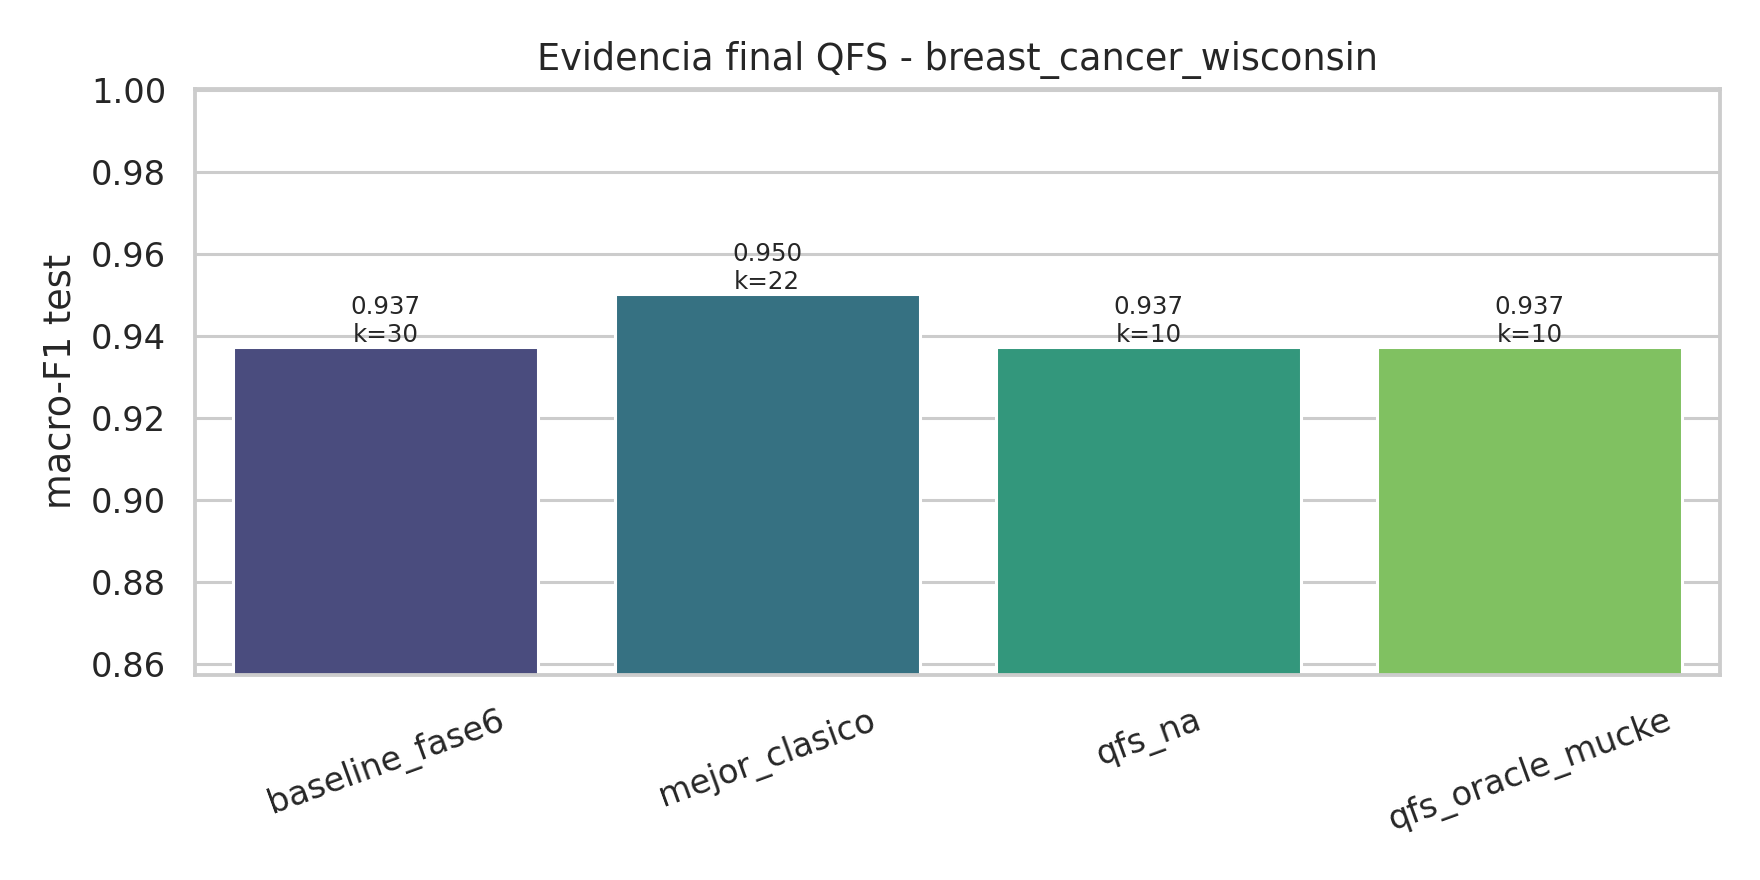

### Evidencia: `breast_cancer_wisconsin`
- Baseline fase 6: macro-F1=0.937 con 30 variables.
- Mejor clasico fase 7: macro-F1=0.950 con 22 variables.
- QFS operativo: macro-F1=0.937, delta=0.000, veredicto=equivalente.
- QFS oraculo: macro-F1=0.937, delta=0.000, veredicto=equivalente.

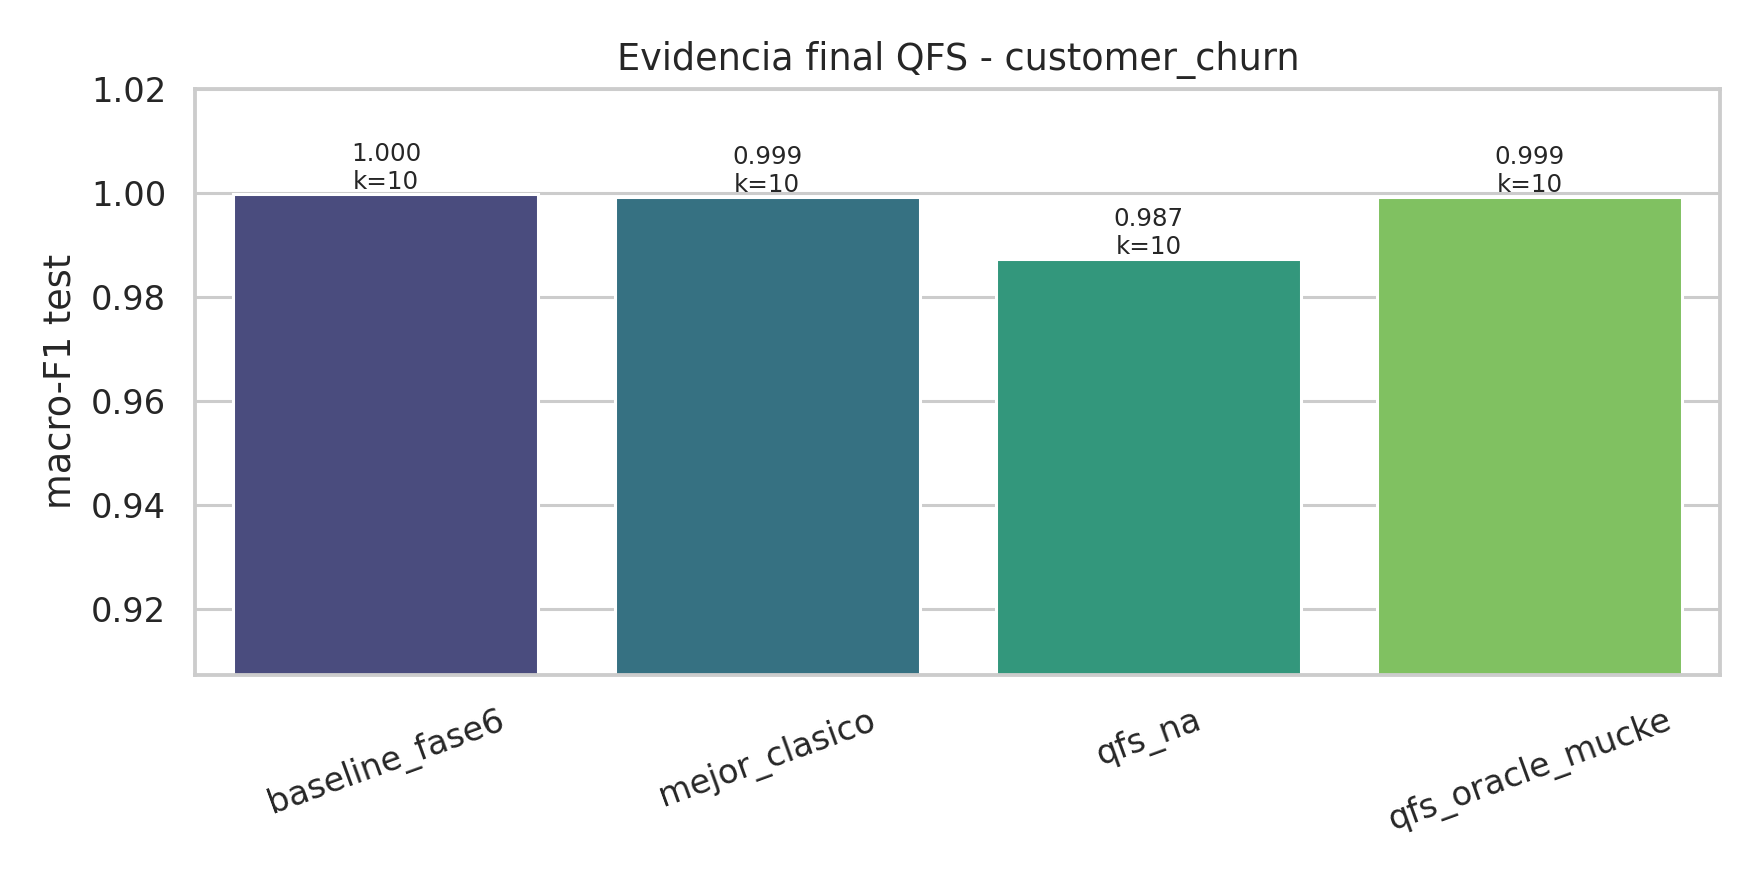

### Evidencia: `customer_churn`
- Baseline fase 6: macro-F1=1.000 con 10 variables.
- Mejor clasico fase 7: macro-F1=0.999 con 10 variables.
- QFS operativo: macro-F1=0.987, delta=-0.013, veredicto=deterioro.
- QFS oraculo: macro-F1=0.999, delta=-0.001, veredicto=deterioro.

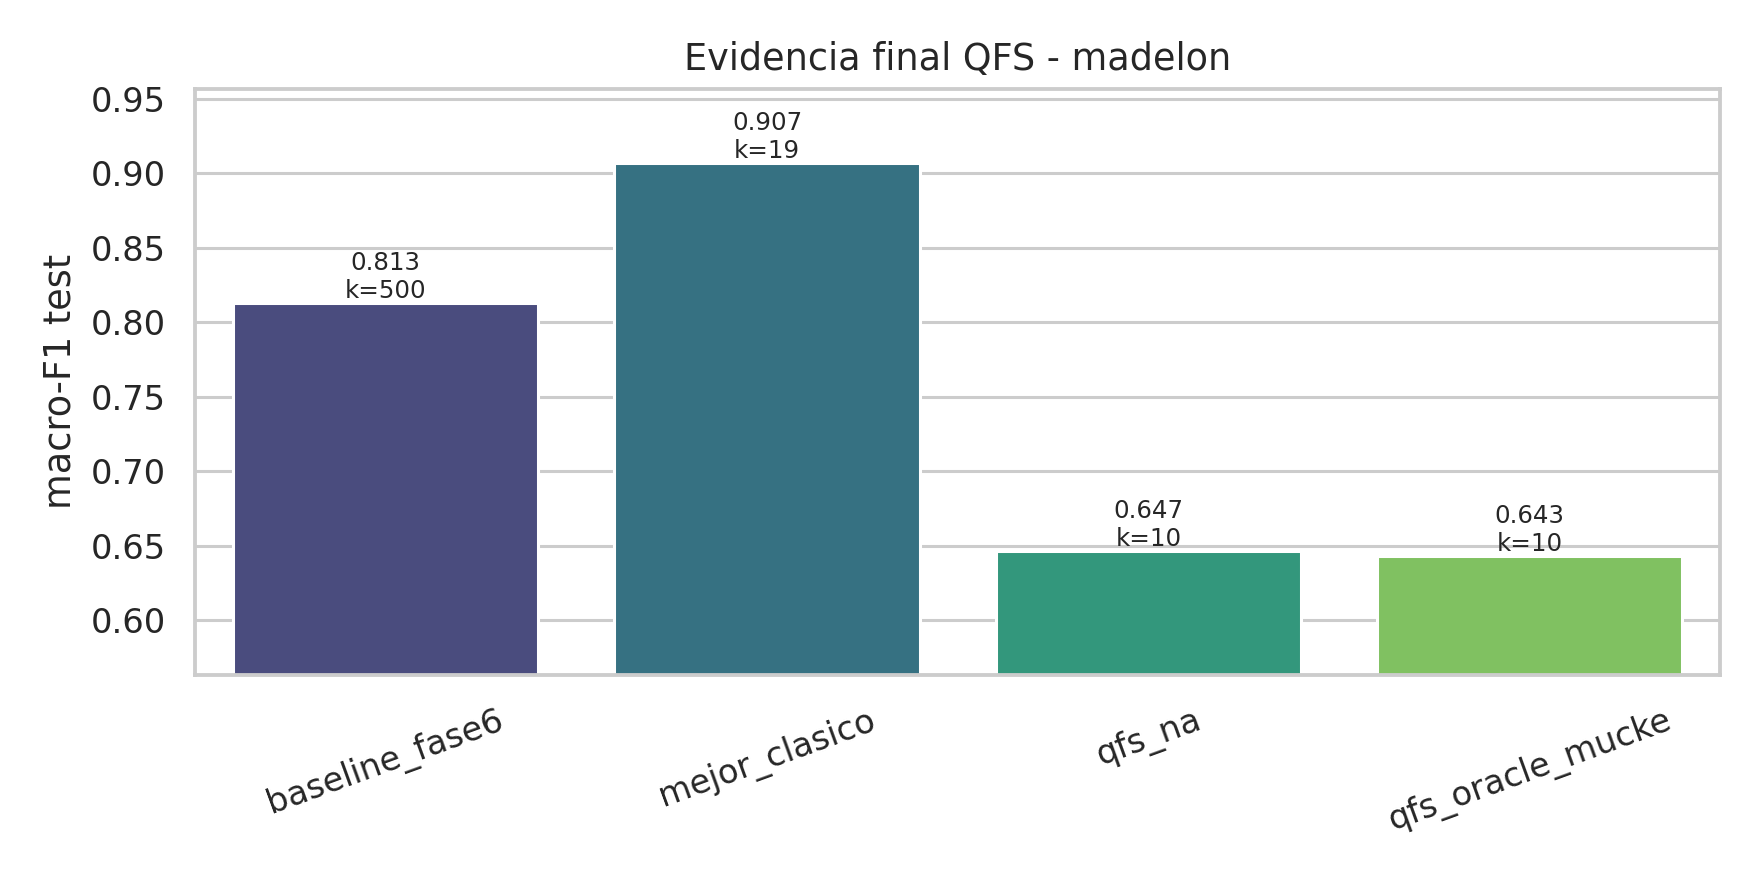

### Evidencia: `madelon`
- Baseline fase 6: macro-F1=0.813 con 500 variables.
- Mejor clasico fase 7: macro-F1=0.907 con 19 variables.
- QFS operativo: macro-F1=0.647, delta=-0.166, veredicto=deterioro.
- QFS oraculo: macro-F1=0.643, delta=-0.170, veredicto=deterioro.

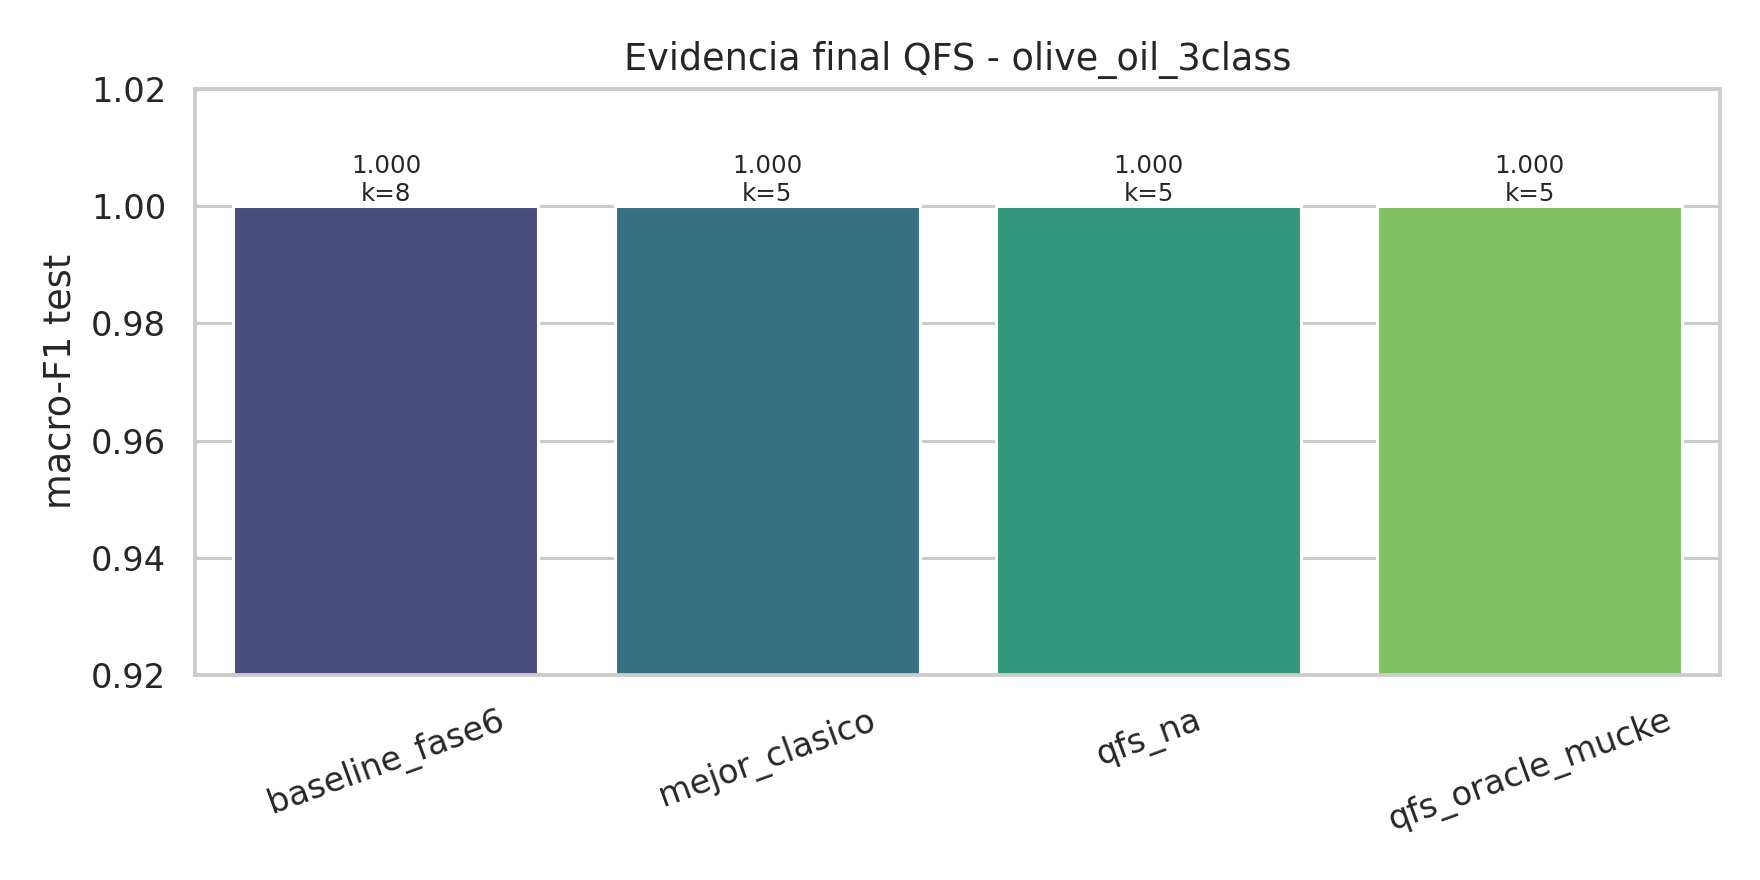

### Evidencia: `olive_oil_3class`
- Baseline fase 6: macro-F1=1.000 con 8 variables.
- Mejor clasico fase 7: macro-F1=1.000 con 5 variables.
- QFS operativo: macro-F1=1.000, delta=0.000, veredicto=equivalente.
- QFS oraculo: macro-F1=1.000, delta=0.000, veredicto=equivalente.

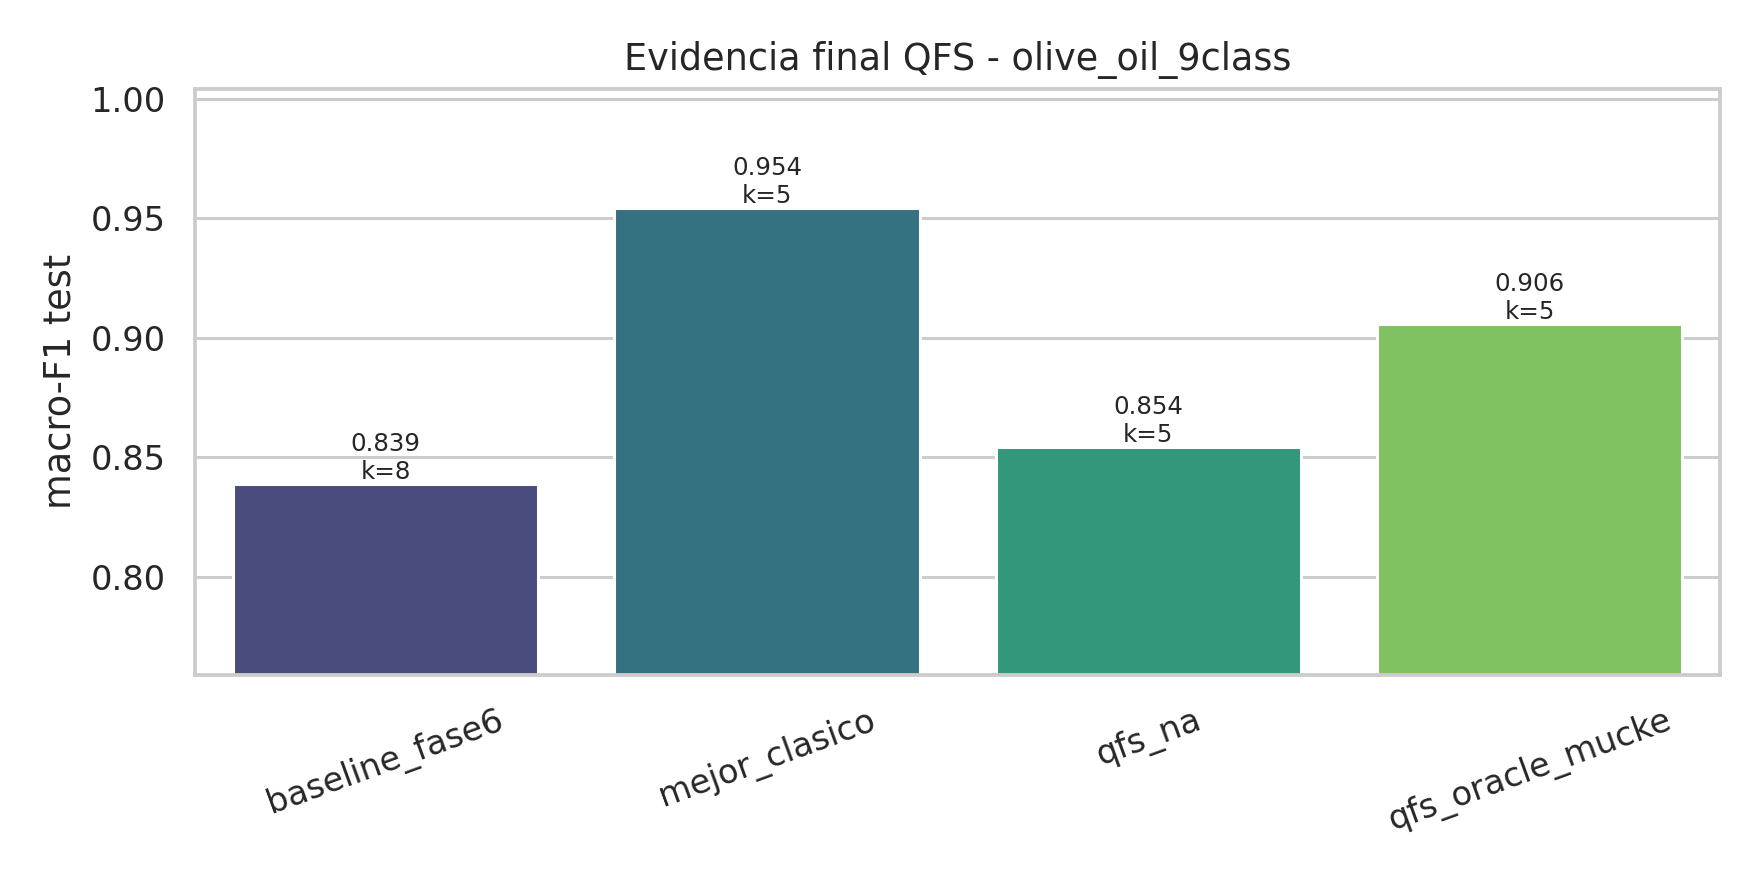

### Evidencia: `olive_oil_9class`
- Baseline fase 6: macro-F1=0.839 con 8 variables.
- Mejor clasico fase 7: macro-F1=0.954 con 5 variables.
- QFS operativo: macro-F1=0.854, delta=0.016, veredicto=equivalente.
- QFS oraculo: macro-F1=0.906, delta=0.067, veredicto=equivalente.

In [6]:
sns.set_theme(style="whitegrid", context="notebook")
for dataset in DATASETS:
    base = baseline_results[(baseline_results["dataset"].eq(dataset)) & (baseline_results["feature_set"].eq("all_features"))].iloc[0]
    clas = classic_final[classic_final["dataset"].eq(dataset)].iloc[0]
    qfs_ds = qfs_final[qfs_final["dataset"].eq(dataset)]
    rows = [
        {"metodo": "baseline_fase6", "macro_f1": base.test_macro_f1, "n_features": base.n_features_used},
        {"metodo": "mejor_clasico", "macro_f1": clas.seleccion_test_macro_f1, "n_features": clas.seleccion_features},
    ]
    for row in qfs_ds.itertuples(index=False):
        rows.append({"metodo": row.configuration, "macro_f1": row.qfs_test_macro_f1, "n_features": row.n_features_used})
    plot_df = pd.DataFrame(rows)
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(data=plot_df, x="metodo", y="macro_f1", hue="metodo", dodge=False, palette="viridis", legend=False, ax=ax)
    ax.set_ylim(max(0, plot_df["macro_f1"].min() - 0.08), min(1.02, plot_df["macro_f1"].max() + 0.05))
    ax.set_title(f"Evidencia final QFS - {dataset}")
    ax.set_xlabel("")
    ax.set_ylabel("macro-F1 test")
    ax.tick_params(axis="x", rotation=20)
    for i, item in plot_df.iterrows():
        ax.text(i, item.macro_f1, f"{item.macro_f1:.3f}\nk={int(item.n_features)}", ha="center", va="bottom", fontsize=8)
    fig.tight_layout()
    png = FIG8 / f"fase9_resumen_evidencia_{dataset}.png"
    fig.savefig(png, dpi=220)
    fig.savefig(png.with_suffix(".pdf"))
    plt.close(fig)
    display(Image(filename=str(png), width=760))

    op = qfs_ds[qfs_ds["configuration"].eq("qfs_na")].iloc[0]
    oracle = qfs_ds[qfs_ds["configuration"].eq("qfs_oracle_mucke")].iloc[0]
    display(Markdown(
        f"### Evidencia: `{dataset}`\n"
        f"- Baseline fase 6: macro-F1={base.test_macro_f1:.3f} con {int(base.n_features_used)} variables.\n"
        f"- Mejor clasico fase 7: macro-F1={clas.seleccion_test_macro_f1:.3f} con {int(clas.seleccion_features)} variables.\n"
        f"- QFS operativo: macro-F1={op.qfs_test_macro_f1:.3f}, delta={op.delta_test_macro_f1:.3f}, veredicto={op.veredicto}.\n"
        f"- QFS oraculo: macro-F1={oracle.qfs_test_macro_f1:.3f}, delta={oracle.delta_test_macro_f1:.3f}, veredicto={oracle.veredicto}."
    ))

## 9.6 AUC Binaria y Limitaciones

In [7]:
auc_rows = []
for dataset in ["breast_cancer_wisconsin", "customer_churn"]:
    base = baseline_results[(baseline_results["dataset"].eq(dataset)) & (baseline_results["feature_set"].eq("all_features"))].iloc[0]
    qfs_ds = qfs_final[qfs_final["dataset"].eq(dataset)]
    auc_rows.append({"dataset": dataset, "fuente": "baseline_fase6", "model_name": base.model_name, "auc_roc": base.test_auc_roc})
    for row in qfs_ds.itertuples(index=False):
        auc_rows.append({"dataset": dataset, "fuente": row.configuration, "model_name": row.qfs_model_name, "auc_roc": row.qfs_test_auc_roc})
auc_table = pd.DataFrame(auc_rows)
auc_table.to_csv(TABLE8 / "qfs_auc_binarios_contexto.csv", index=False)
display(auc_table)

,dataset,fuente,model_name,auc_roc
0,breast_cancer_wisconsin,baseline_fase6,linear_svm,0.976273
1,breast_cancer_wisconsin,qfs_na,random_forest,0.962095
2,breast_cancer_wisconsin,qfs_oracle_mucke,linear_svm,0.959491
3,customer_churn,baseline_fase6,xgboost,0.999999
4,customer_churn,qfs_na,xgboost,0.995052
5,customer_churn,qfs_oracle_mucke,xgboost,0.999974


La lectura AUC se limita a los dos datasets binarios. La fase cuantica sigue siendo simulacion analogica local, no hardware real; `breast_cancer_wisconsin` y `madelon` son hibridos por preseleccion `mrmr_approx_k20`; `beta` se barre en 11 valores discretos; y el oraculo exacto es completo porque todos los problemas entran a QFS con 20 variables o menos.